# Single-contact spike detection (Real Data, CH19)
**The Goal** is to detect the firing of one known nerve fibre in a real rat saphenous nerve recording. This notebook only experiments on one channel, which is channel19. 
**The ground truth**: the lab marked 1,623 spikes for this unit. Here, the detections were tested against those markes. 
**The code difficulty encountered in this notebook in five ways:** the electrode picks up many fibres at once, so on a single channel  its diffecult to tell which fibre a given spike came from.
## Notebook Order


# Glossary 
## Windows
| Window | Code | What is measures | Between |
|----|----|----|----|
| 3 ms refractory | 'distance=90' | minimum gap so one spike is not counted twice | detection <-> detection|
| +/-2ms tolerance (field standard) | 'tolerance=0.002' in 'score_detection' | how close a detection must be to a true spike to be scored as correct | detection <-> ground_truth |
| 5 ms latency window | 'lat_min98.1, lat_max=103.1' in 'in_latency_window' | whether detection falls in the fixed delay after the stimulus | detection<-> stimulus|
-----------------------------------------------------------------------------------------------------
## Variables
| Variable | Type | Size | what it holds |
|----|----|----|----|
| 'scores' | ndarray | 9,000,000 | match score at every sample (-1 to 1) |
| 'peaks' | ndarray | 64, 183 | sample posittion where score peaked (intergers) |
| 'peak_times' | ndarray | 64, 183 | time of each peak in seconds |
| ' ground_truth_in_window' | ndarray | 71 | true spike times in seconds |
|'sample_frequency' | number | 1 | 30000, sample per seconnd |
| 'window_start' | number | 1 | 3602.6708, recording start time in seconds |


In [1]:
#imports 
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
import h5py

from src.evaluate import detect_spikes, score_detections
from scipy.signal import correlate, find_peaks
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import KFold
from sklearn import svm
from scipy.signal import resample
from scipy.ndimage import uniform_filter1d
from sklearn.svm import OneClassSVM
from src.denoisers import denoise_wavelet_channel
import torch
import torch.nn as nn
import pywt

path = r"C:\spike-denoising-synthetic\data\real"
sample_frequency = 30000 

# 1. Setup and data 
Load the recording and the ground truth. The data is one file per channel (float64, 30 kHz), already filtered (300-6000 Hz), and artefacts were blanked by the lab. 
ground truth is a MATLAB v7.3 file, and read by h5py

Here I worked on a 300 second window starting at stimulus 900, which is a stable stretch of the recording. All the times share one clock, and this is was verified against time_series_2.bin (starts at 1.03s, 30 kHz spacing)
### Files:
1. time_series_2.bin : the time information of the data recordings
2. 100_RhythmData_CH19_2_filtered_blanked.bin : the data recordings from channel 19
3. grouped_unit_1.mat : describes the time points of a 'good' unit which has large spikes on multiple data channels
4. 'aligned_zc_locs' which will describe when (i.e., at what time) the spike was detected on that channel. These time points will match with the 'time_series_2.bin' file

In [2]:
#Load the ground truth
ground_truth = h5py.File(path + r"\grouped_unit_1.mat", "r") # Describes the time point of a "good" unit which has large spikes
print("List of field names inside the file:", [k for k in ground_truth.keys() if not k.startswith("#")])
zc_ch19 = ground_truth["CH19"]["aligned_zc_locs"][:].flatten() # aligned zero-crossing locations

print("Spikes on CH19:", len(zc_ch19)) # ground truth spikes
print("time range (s): %.1f to %.1f" % (zc_ch19.min(), zc_ch19.max())) # 

List of field names inside the file: ['CH10', 'CH14', 'CH19', 'CH25', 'CH3', 'CH30', 'CH9', 'filename', 'group_number', 'primary_channel']
Spikes on CH19: 1623
time range (s): 1754.5 to 8265.2


In [3]:
# Define the window
ttls = np.fromfile(path + r"\TTLs_2.bin", dtype='<f8') # load stimulus pulse times from the file 

print("number of TTLs:", len(ttls)) # totsal stimulus pulses in the whole recording
print("spacing (s):", np.diff(ttls[:5])) # The gap between the first five pulses

# MATLAB counts from 1, PYTHON from 0
print("ttls[792]:", ttls[792])  
print("ttls[900]:", ttls[900]) 

window_start = ttls[900]   # the time of pulse index 900, so the 300-second window begins at the 900th stimulus pulse 
window_end   = window_start + 300 # the window ends 300 seconds after it starts

print("window: %.2f to %.2f s" % (window_start, window_end)) # print window starta nd end time
print("stimuli in window:", ((ttls >= window_start) & (ttls <= window_end)).sum()) # count how many stimulus pulses in side the 300 second window

number of TTLs: 2310
spacing (s): [4.0007     4.0007     4.00073333 4.0007    ]
ttls[792]: 3170.5945666666667
ttls[900]: 3602.6708
window: 3602.67 to 3902.67 s
stimuli in window: 75


## The loaded window:
9,000,000 samples (300 s), noise floor MAD 4.92, 71 ground truth spikes inside the window. These are what every method below is scored against

In [ ]:
# Load CH19 for the 300-second window
ch19_file = path + r"\100_RhythmData_CH19_2_filtered_blanked.bin" # prefiltered and artefact blanked
start_indx = int(window_start * sample_frequency) # Convert window start time (3602s) into sample index (mapping the timestamp to a position)

n_samples = int(300 * sample_frequency) # How many samples in 300 seconds window (300 x 30000 (sample_frequency) = 9,000,000 samples). 
ch19 = np.fromfile(ch19_file, dtype='<f8', count=n_samples, offset=start_indx * 8) # load Ch19 on that window

window_end = window_start + len(ch19) / sample_frequency      
noise_mad = np.median(np.abs(ch19)) / 0.6745  # MAD is the noise estimate for this window
ground_truth_in_window = zc_ch19[(zc_ch19 >= window_start) & (zc_ch19 <= window_end)] # Ground truth spikes between the start and the end of the window

print("samples loaded:", len(ch19)) # 9,000,000
print("seconds: %.1f" % (len(ch19) / sample_frequency)) # 300
print("noise (MAD): %.2f" % noise_mad) # noise floor 
print("ground-truth spikes in window:", len(ground_truth_in_window)) # the ground truth spikes in the window


# 2. Characterise the spikes
This section measures how deep the ground truth spikes are. 
To look at the depth of the spike:
To hold a full spike, a 3 ms clip is chosen; 3 ms at 30 kHz is 90 samples.  

**A spike is captured in a 3 ms window. At the 30 kHz sampling rate, 3 ms corresponds to 90 samples (0.003 s × 30 000 = 90). This window is centred on the spike, with half_width = 45 samples (1.5 ms) taken on each side.**

In Extracellular recordings that measure extracellular potentials, when an axon fires an action potential, positive sodium ions rush into the cell at the active region. This leaves the extracellular space near the electrode locally negative, which the electrode records as a downward deflection. So, because of the negative-going spike amplitudes: **(5th Percentile)** is the lowest numerical value, meaning it is the largest negative drop. Physically, representing deepest, the highest-amplitude, strongest spikes (furthest away from 0).**(95th Percentile)**: This is closer to zero and represents the shallowest, smallest spikes that sit right on the edge of the background noise floor.

Once the absolute value is taken in the code (np.abs(depths)), these mathematical positions flip, on the transformed positive scale, where the 5th percentile becomes the shallow spikes and the 95th percentile becomes the deep spikes

In [5]:
# Characterise the spikes: for each ground truth spike time in the window, convert to a sample index
half_width = 45  # Samples to take each side of each spike. 45 samples = 1.5ms at 30 kHz. 

depths = [] # empty list to collect each spike's depth
for spike_time in ground_truth_in_window:
    spike_index = int((spike_time - window_start) * sample_frequency)  # Convert this spike's time to a sample index within the loaded window 
                                                    # Find where a spike sits inside ch19, subtract the window's start time, then multiply by the frequency.  
    
    spike_segment = ch19[spike_index - half_width : spike_index + half_width] # Cut a 90 sample window out of Ch19 centred on the spike. 
    if len(spike_segment) == 2 * half_width:  # Only keep full length segments, so skip spikes too close to the window edge to cut a full 90 samples
        depths.append(spike_segment.min()) 
depths = np.array(depths) # The trough of each spike
ratios = np.abs(depths) / noise_mad # each depth divided by the MAD noise floor, so how many times the noise level each spike goes. 

print("spikes measured:", len(depths)) # How many spikes got meausred 
print("median depth: %.2f (%.2f x noise)" % (np.median(depths), np.median(ratios))) # median depth and median depth relative to the noise
print("5th percentile:  %.2f x noise" % np.percentile(ratios, 5)) #shallow spikes 
print("95th percentile: %.2f x noise" % np.percentile(ratios, 95)) # deepest spikes

spikes measured: 71
median depth: -11.32 (2.29 x noise)
5th percentile:  1.45 x noise
95th percentile: 3.51 x noise


# 3. Detection by depth
This part is in three stages: 
First, detect spikes: find where the signal first dips below -k x noise, drop any dip that starts closer than 3 ms to the previous kept one and return the survivors as times in seconds.
**crossings:** contains everything that crossed the threshold.
**keep:** then it holds only the crossings from that list that are at least 90 samples after the last kept crossing (the refractory 3 ms) to remove duplicates.

Second, for each detection score, look for a nearby unclaimed true spike; if found, count a hit and claim that spike; then count the hits, false alarms, and misses and turn them into precision, recall and F1.
NOTE: The detector runs two rules:
1. threshold: signal drops below -1.5 x noise floor -> detect
2. Refractory: after a detection, ignore everything for ms to prevent counting the same spike more than once

Third, threshold sweep for detection
It tests the amplitude detector at five different threshold strengths and scores each one against the ground truth to see how detection quality changes as the threshold gets stricter. 

## Results: 
Detected spikes: ~76,000 at k=1.5 down to ~5,000 at k=4
Recall: 0.887 at k=1.5 to ~0.056 at k=4
Precision: stays flat near zero 
F1: 0.002 across all thresholds. 

## Opinion:
If false positives are noise, when the threshold is raised, it would have removed them and returned high precision. But precision stays near zero regardless of how strict the threshold is. This suggests that false positives are not noise but other fibres with similar amplitude to the target unit that cross the threshold at every k. 


In [6]:
# Helper functions for finding the spikes and scoring them against the ground truth in the window. 
def detect_spikes(data, sample_frequency, k=4, noise_std=None, refractory_ms=3.0):
    """
    Detect spikes by amplitude threshold on a negative-going signal.
    Flag every point where the signal drops below -k * noise, then enforces a refractory period so a single spike crossing the threshold more than once its counted as one

    Args:
        data (np.ndarray): 1D signal (one channel)
        sample_frequency (int): sampling rate in Hz (30000)
        k (float): threshold multiplier; lower catches more, higher is stricter. 
        noise_std (float or None): noise level; if None, estimated as MAD = median(|data|)/0.6745.
        refractory_ms (float): minimum gap between detections in ms.
    """
    if noise_std is None:
        noise_std = np.median(np.abs(data)) / 0.6745 # MAD: absolute value of every sample, take the median, divide by 0.6745
    threshold = -k * noise_std     # the cutoff a sample must go below to count
    below = data < threshold       # boolean mask, True where the signal is below the threshold
    crossings = np.where(np.diff(below.astype(int)) == 1)[0] + 1 # find the start of each dip, turn True/flase into 1/0; below the threshold is 1, above is 0. so, when 0 -> 1 = signal first drops below the line 
                                                                # np.diff() subtract each sample from the next, so a step from 0 up to 1 shows as +1 and 1 to 0 as -1. 
                                                                # == 1 keeps only the +1
                                                                # np.where()[0] returns the index position where that is true
                                                                # +1 shifts each index forward by one, because np.diff reports a change at the sample just before it happens
    min_gap = int(refractory_ms * sample_frequency / 1000)  # refractory period in samples (3ms -> 90)
    keep = []  # collect kept crossings
    last = -min_gap # index of the last kept crossing
    for crossing in crossings: 
        if crossing - last >= min_gap: # keep the crossings only if it's at least 90 samples after the last kept one, if kept 
            keep.append(crossing)      
            last = crossing        #if kept, record it and update
    return np.array(keep) / sample_frequency  # The kept values are divided by the sample frequency (30000), which turns them into seconds. 

def score_detections(detected, ground_truth_times, tolerance=0.002): 
    """
    Score detections against ground truth spike times
    Each detection is matched to a ground truth spike within tolerance.

    Args:
        detected (np.ndarray): detection times in seconds 
        ground_truth_times (np.ndarray): ground truth target spike times in seconds 
        tolerance (float): match window in seconds (e.g. 0.001 = +/- 1 ms)

    Returns:
            tuple(float, float, float): precision, recall, f1
                precision = tp/(tp+fp), recall = tp/(tp+fn), f1 = harmonic mean
    """
    matched_true = set() # A set that remembers which true spikes have already been claimed by a detection 
    tp = 0  # True-positive counter (hits) starts at 0
    for detection in detected: # Go through each detection
        close = np.where(np.abs(ground_truth_times - detection) <= tolerance)[0] # find true spiks near tis detection
        unmatched = [ground_truth_index for ground_truth_index in close if ground_truth_index not in matched_true] # Of those nearby true spikes, only keep the ones that are not already claimed by an earlier detection. 
        if len(unmatched) > 0: # if there's at least one unclaimed true spike nearby, this detection is a hit:
            tp += 1                        # count it as a true positive
            matched_true.add(unmatched[0]) # claim the first available true spike (mark it used,so no other detection can claim it) 
    fp = len(detected) - tp # false positives = detections that didn't hit anything (total detections - the hits)
    fn = len(ground_truth_times) - len(matched_true) # false negative = true spikes that got missed. Total true spikes - the ones that got claimed. 
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0 # precision = of everything detected, how many were real. 
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0 # Recall = of all the true spikes, how many were caught 
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0 # F1 = the harmonic mean of precision and recall. 
    return precision, recall, f1

In [7]:
# threshold detection sweep
# Run amplitude detector at five different thresholds and score each one

print(f"{'k':>5s} {'detected':>9s} {'precision':>10s} {'recall':>8s} {'F1':>7s}") 
for k in [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4]: # low k (0.5) = loose threshold catches lots of spikes. High k (4) is strict, so it only catches bigger dips. 
    #  detect at this threshold
    depth_detections = detect_spikes(ch19, sample_frequency, k=k) + window_start # run detector on the signal at this k, returs detetcions times relative to the window start
    precision, recall, f1 = score_detections(depth_detections, ground_truth_in_window, tolerance=0.002) # compare the detections to the ground truth spikes, with a +/- 2ms match window and return three mertics for this k.
    print(f"{k:5.1f} {len(depth_detections):9d} {precision:10.4f} {recall:8.3f} {f1:7.3f}")
    if k == 1.5:
        number_detections_depth = len(depth_detections)
        precision_depth = precision
        recall_depth = recall
        f1_depth = f1

    k  detected  precision   recall      F1
  0.5     91633     0.0008    1.000   0.002
  1.0     87052     0.0008    0.986   0.002
  1.5     76540     0.0008    0.887   0.002
  2.0     57028     0.0009    0.718   0.002
  2.5     33923     0.0009    0.451   0.002
  3.0     17456     0.0010    0.254   0.002
  3.5      9041     0.0007    0.085   0.001
  4.0      5219     0.0008    0.056   0.002


# 4. Template Matching (Detection by shape)
### Threshold detection alone did not tell the target spike from other events, so this stage matches on shape instead of depth. 
This section, uses normalised cross-correlation trough aligned template (aligns each spike ot its trough) by building one average spike waveform (the template) from the 71 ground truth spikes. 
1. **Template_match** slides the template along the whole recording and, at every sample, measures how similar the signal there is to the template shape, and the output is a score at every sample running from -1 to +1, where high means the signal looks like a spike.
2. The score is a normalised correlation (Pearson), so it responds to shape, not amplitude, so a big spike and a small spike with the same shape both score high.
3. **find_peaks(scores, height=0.3, distance=90)**: finds the peaks in the score signal: local maxima at least 0.3 high and at least 90 samples (3ms refractory) apart, which converts the continuous score into a list of discrete detection positions. Producing 64,183 shape detections across the 300 s window. (Height 0.3 was chosen because when sweeping the shape threshold from 0.3 to 0.7, recall went from 0.77 to 0.042, while precision stayed around 0.001), so a stricter threshold discards target spikes without removing the false positives. 



In [8]:
#helper function for template matching

def template_match(signal, template):
    """
    Normalised cross-correlation between template and a signal
    Slides the zero-mean, unit-norm template along the signal and returns a match score at every sample. 

    Args:
        signal (np. ndarray): 1D signal to search
        template (np.ndarray): the average spike waveform to match. 

    Return:
        np.ndarray: match score in [-1, 1] at each sample.
    """
    template_centred = template - template.mean() #subtract the average so the template sits centred on zero, with equal weight above and below 
    template_unit = template_centred / np.linalg.norm(template_centred) # divide by its length (the square root of the sum of squared), so the template size 1 
                            # zero means removes the offset and unit norm removes the scale, together they turn a raw dot product into a proper correlation that lives in [-1. 1]
    template_length = len(template_unit) # template length in samples. 
    raw_match = correlate(signal, template_unit, mode='same') # At every position along the signal, slide the template, multiply and sum template against signal at every position, and give one value per sample. 
    
    # Measure the signal's size at every position, how big the signal is in each template width window. 
    local_mean   = uniform_filter1d(signal,    template_length, mode='nearest') # signal's local mean. Slide a window of width along the signal and average the values inside it.                                                   
    local_mean_sqr  = uniform_filter1d(signal**2, template_length, mode='nearest') #local mean of the signal squared
    local_variance = np.maximum(local_mean_sqr - local_mean**2, 0)  #local variance = (mean of squares) - (mean squared) and clipped at 0, so rounding cant make it negatie
    local_norm = np.sqrt(local_variance * template_length) 
    return np.divide(raw_match, local_norm, out=np.zeros_like(raw_match), where=local_norm > 1e-6) # Raw match / signal size = the final shape score [-1, 1]

def spike_latencies(spike_times, ttls):
    """
    Latency of each spike from the stimulus pulse
    For each spike, finds the most recent stimulus (TTL) before it and returns the time difference. 

    Args:
        spike_times (np.ndarray): spike times in seconds
        ttls (np.ndarray): stimulus pulse times in seconds

    returns :
        latency of each true spike in seconds
    """
    indx = np.searchsorted(ttls, spike_times) - 1
    ok = indx >= 0
    lat = spike_times[ok] - ttls[indx[ok]]
    return lat

# The latency constraint 
def in_latency_window(times, ttls, lat_min=0.085, lat_max=0.160):
    """
    for each detection, True if it fired at the right delay after a stimulus (between lat_min and lat_max), 
    false otherwise
    
    Args:
        times (np.ndarray): detection times in seconds 
        ttls (np.ndarray): stimulus pulse times in seconds
        lat_min (float): lower latency bound in seconds
        lat_max (float): upper latency bound in seconds

    return:
        np.ndarray: true where the detection's latency falls in the window
        The wide window (0.085-0.160); the tight bound is passed for a 5 ms window.  
    """
    indx = np.searchsorted(ttls, times) - 1
    has_ttl = indx >= 0
    latency = np.full(len(times), np.inf)
    latency[has_ttl] = times[has_ttl] - ttls[indx[has_ttl]]
    return (latency >= lat_min) & (latency <= lat_max)
    

In [9]:
# Build the template
half_width   = 45      # 1.5 ms template width on each side of the trough
align_window = 30      # 1 ms to find the real trough, because the marked spike times might be a bit off the true deepest point. 

spike_segments = [] # holds one clip per spike
for spike_time in ground_truth_in_window: # convert spike's time (seconds) to sample index in ch19: subtract the window start
    centre_index = int((spike_time - window_start) * sample_frequency) # then multiply by sample frequency to turn seconds into samples
    
    # cut a chunk wider than the final clip, leaving room to search for the trough
    lo, hi = centre_index - half_width - align_window, centre_index + half_width + align_window
    if lo < 0 or hi > len(ch19): # skip spikes that are too near the recording edge
        continue
    wide_window   = ch19[lo:hi]
    # look in align_window each side of the centre, find the deepest sample (the trough)
    centre = half_width + align_window # middle of the wide_window where the marked spike sits
    trough_index = np.argmin(wide_window[centre - align_window : centre + align_window]) + (centre - align_window)
    
    # Cut 45 samples each side of the trough, a 90 sample clip centred on the deepest point. 
    spike_segment = wide_window[trough_index - half_width : trough_index + half_width]
    if len(spike_segment) == 2 * half_width:
        spike_segments.append(spike_segment)

spike_segments = np.array(spike_segments) # Stack all the clips into an array, then average down the columns. 
template = spike_segments.mean(axis=0) # the average is the template. 

print("spikes averaged:", len(spike_segments))  
print("template trough: %.2f" % template.min())
print("trough / noise:  %.2f" % (abs(template.min()) / noise_mad)) # how deep is the spike compared to the noise. 

spikes averaged: 71
template trough: -11.31
trough / noise:  2.29


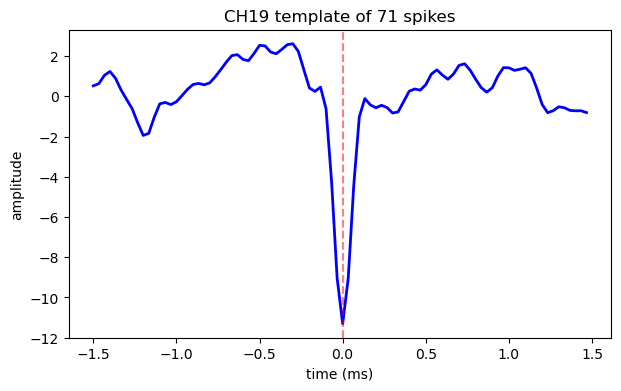

In [10]:
# plot the template 
time_ms = (np.arange(2 * half_width) - half_width) / sample_frequency * 1000
plt.figure(figsize=(7, 4))
plt.plot(time_ms, template, 'b', linewidth=2)
plt.axvline(0, color='r', linestyle='--', alpha=0.5)
plt.xlabel('time (ms)'); plt.ylabel('amplitude')
plt.title('CH19 template of %d spikes' % len(spike_segments))
plt.show()

In [11]:
# Runthe over the whle signal and check the score range
scores = template_match(ch19, template)
print("score range: %.3f to %.3f" % (scores.min(), scores.max()))
print("zeroed samples:", (scores == 0).sum())

score range: -0.824 to 0.865
zeroed samples: 480


In [12]:
# Similarity threshold sweep 
# height=th is the shape similarity threshold: find_peaks keeps only peaks scoring at least th (-1 to +1). 
# Higher th = stricter match, so only spikes very similar to the template are kept
# Lower th = looser match, more peaks (more false positives). 

print(f"{'thresh':>7s} {'detected':>9s} {'precision':>10s} {'recall':>8s} {'F1':>7s}")
for th in [0.3, 0.4, 0.5, 0.6, 0.7]: # try five different similarity thresholds 
    peaks, _ = find_peaks(scores, height=th, distance=90) # find peaks in the match score signal. Only keep peaks scoring at least 'th' (threshold)  
    shape_detections = peaks / sample_frequency + window_start # Convert peak sample positions to absolute time in second
    precision, recall, f1 = score_detections(shape_detections, ground_truth_in_window, tolerance=0.002) # score this threshold's detections against the 71 true spikes, +/-2 ms match tolerence 
    print(f"{th:7.1f} {len(peaks):9d} {precision:10.4f} {recall:8.3f} {f1:7.3f}")

 thresh  detected  precision   recall      F1
    0.3     64183     0.0009    0.775   0.002
    0.4     49626     0.0009    0.662   0.002
    0.5     26248     0.0012    0.451   0.002
    0.6      8709     0.0014    0.169   0.003
    0.7      1664     0.0018    0.042   0.003


## 5. Latency constraint
Template matching (shape) kept the target spikes but also detected other events, so precision is low, as seen in the similarity scores above. The target fibres fire at a consistent delay after each stimulus, which other fibres do not share, so this latency constraint stage filters detections by timing to remove them. So the contrast and shape could not separate target spikes from other events, but timing can; this is the point of this section. 
### Three steps to do this:
1. **Measure each detection's latency**: for every detection, find the stimulus pulse just before it and measure the delay between them. That delay is the latency. 
2. **Only keep detections in the latency band**: so a detection is kept only if its latency falls within a window around the target's typical delay.
3. **Why that width**: A 5 ms width was chosen because it kept eighty detections, which is closest to the ground truth spikes, and precision was still high.

### Results:
Shape alone gave 64,183 detections at precision 0.0009; the tight latency window cuts this to 80 detections at precision 0.662, recall 0,745 and F1 0.702. 


In [13]:
# Find the best latency window: centre on the median ground truth latency, and sweep the half_width
#in_latency_window expects seconds; lo/hi are converted to seconds (/1000) on their line
# both ground_truth_latency and median_latency are in ms

ground_truth_latency = spike_latencies(ground_truth_in_window, ttls) * 1000 # take the 71 target spikes and compute each one's latency and convert them from s to ms
median_latency = np.median(ground_truth_latency) 
peaks, _ = find_peaks(scores, height=0.3, distance=90) # scan the match score signal and return the sample positions of every shape match,
                                                    # that is both at least 0.3 strong and 90 samples (3ms) apart from the next 
print("shape detections (before latency:", len(peaks))
shape_detections = peaks / sample_frequency + window_start #convert those peak positions from sample indices into absolute times in seconds. 

print(f"{'window (ms)':>16s} {'width':>6s} {'kept':>6s} {'precision':>10s} {'recall':>8s} {'F1':>7s}")
for latency_half_width in [0.5, 1.0, 1.5, 2, 2.5, 3, 3.5, 4, 5, 6, 7]: # try each half_width in turn in ms. How far each side of the median is accepted
    lo, hi = (median_latency - latency_half_width)/1000, (median_latency + latency_half_width)/1000 #lo = median minus the half_width, hi = median plus the half_width
                                                                                                    # both are converted from ms to seconds. 
    
    latency_detections = shape_detections[in_latency_window(shape_detections, ttls, lat_min=lo, lat_max=hi)] # only keep the shape detection where post stimulus latency falls in [lo, hi] 
    precision, recall, f1 = score_detections(latency_detections, ground_truth_in_window, tolerance=0.002) # score detections against the 71 ground truth spikes , +/- 2ms tolerance.
    print(f"  {median_latency-latency_half_width:.1f}-{median_latency+latency_half_width:.1f} {2*latency_half_width:6.0f} {len(latency_detections):6d} {precision:10.3f} {recall:8.3f} {f1:7.3f}")

shape detections (before latency: 64183
     window (ms)  width   kept  precision   recall      F1
  100.1-101.1      1     23      0.870    0.282   0.426
  99.6-101.6      2     33      0.879    0.408   0.558
  99.1-102.1      3     53      0.830    0.620   0.710
  98.6-102.6      4     59      0.763    0.634   0.692
  98.1-103.1      5     80      0.662    0.746   0.702
  97.6-103.6      6     97      0.557    0.761   0.643
  97.1-104.1      7    110      0.491    0.761   0.597
  96.6-104.6      8    126      0.437    0.775   0.558
  95.6-105.6     10    153      0.359    0.775   0.491
  94.6-106.6     12    186      0.296    0.775   0.428
  93.6-107.6     14    209      0.263    0.775   0.393


In [14]:
# Tight latency constraint
# Apply the chosen 5ms window (98.1-103.1 ms)
tight_lo = (median_latency - 2.5) / 1000 # take the median latency, subtract 2.5ms (half_width) to get the lower bound (98.1ms), then convert ms to seconds
tight_hi = (median_latency + 2.5) / 1000 # same thing just median pluse 2.5ms
# Apply the constraint
tight_detections = shape_detections[in_latency_window(shape_detections, ttls, lat_min=tight_lo, lat_max=tight_hi)]
precision, recall, f1 = score_detections(tight_detections, ground_truth_in_window, tolerance=0.002) # score detection against thr 71 spikes 

tp = round(recall * len(ground_truth_in_window)) #target spikes caught
fp = len(tight_detections) - tp  # detections kepat that are not target spikes
fn = len(ground_truth_in_window) - tp # target spikes missed

print("tight latency window: %.1f-%.1f ms" % (median_latency - 2.5, median_latency + 2.5))
print("kept: %d   TP: %d   FP: %d   FN: %d" % (len(tight_detections), tp, fp, fn))
print("precision: %.3f   recall: %.3f   F1: %.3f" % (precision, recall, f1))

tight latency window: 98.1-103.1 ms
kept: 80   TP: 53   FP: 27   FN: 18
precision: 0.662   recall: 0.746   F1: 0.702


In [15]:
print("type:", type(scores))
print("shape:", scores.shape)
print("dtype:", scores.dtype)
print("first 5:", scores[:5])
print("min, max:", scores.min(), scores.max())

type: <class 'numpy.ndarray'>
shape: (9000000,)
dtype: float64
first 5: [-0.20624003 -0.21766063 -0.16383952 -0.05237974  0.06949362]
min, max: -0.823541569875564 0.8654700280240578


In [16]:
# Validation check
# check 1: does the time-to-index conversion land on a real spike
spike_time = ground_truth_in_window[0]   # first true spike time
centre_index = int((spike_time - window_start) * sample_frequency) # where does the spike sit within the score array
print("first spike_time :", spike_time)
print("centre_index     :", centre_index, " (a whole number, 0 to 9,000,000)") # the spike sits at what position
print("score at that idx:", scores[centre_index]) # what is the match score at that position? low = weak match, high = high match
print("max near it:", scores[centre_index-90:centre_index+90].max()) # what about at a small window around the position, is there a match? 


first spike_time : 3602.7732333333333
centre_index     : 3073  (a whole number, 0 to 9,000,000)
score at that idx: 0.05912123404340945
max near it: 0.44453973079423786


In [17]:
#validation check
# Check 2: Do the inputs have the right type, length and units
print("ground_truth_in_window") 
print("type:", type(ground_truth_in_window))
print("len:", len(ground_truth_in_window), " (sould be 71)")
print("first 5:", ground_truth_in_window[:5], " (should be times in seconds, ~3602)")
print()
print("window_start")
print(" value:", window_start, " (should be ~3602.6)")
print()
print("sample_frequency")
print("  value:", sample_frequency, " (should be 30000)")
print()
print("scores")
print("len:", len(scores), " (should be 9,000,000)")
print("range:", scores.min(), "to", scores.max(), " (should be within -1 to 1)")

ground_truth_in_window
type: <class 'numpy.ndarray'>
len: 71  (sould be 71)
first 5: [3602.77323333 3606.7741     3610.7746     3618.77576667 3622.7765    ]  (should be times in seconds, ~3602)

window_start
 value: 3602.6708  (should be ~3602.6)

sample_frequency
  value: 30000  (should be 30000)

scores
len: 9000000  (should be 9,000,000)
range: -0.823541569875564 to 0.8654700280240578  (should be within -1 to 1)


# 5. Overlapping 
**Consumes:** peaks, scores, ground_truth_in_window, peak_times, sample_frequency, window_start
**Does:**
1. tests how wide the search window must be to catch each spike's peak
2. measures the score at each true spike vs at all other detections and compares distributions
3. Computes d-prime between target and non-target detections
4. 
**produces**:
1. The width test produces the chosen search window +/-90
2. The overlap diagnostic produces two distributions: true spike median 0.519 and all peaks median 0.475
3. The d-prime : is_target (64183 bool), target_scores (~57), nontarget_scores(~64126), d_prime(0.296)

### NOTE:
***Aksenova et al., 2003: Overlapping spikes are a recognised limitation that degrades sorting performance, and their method did not address it.*** 
### What does d-prime do and how 
Normally, d-prime measures how well spike sorting separates one unit's cluster from others, computed on waveform principal components using LDA. Higher values mean the unit is better isolated. 

Here, because only one template and one match score axis is available, the same separation formula was applied to the 1D match score, comparing target detections (near a true spike) and non-targets (everywhere else). If shape matching (template matching) worked, targets should score high and non-targets low. If it fails, the two will score similar numbers. It gives a single number of how separable are targets from non targets on the shape score. 
Formula: d_prime = (target_scores.mean() - nontarget_scores.mean()) / np.sqrt(0.5*(target_scores.var() + nontarget_scores.var()))

In [18]:
# How wide does the search window need to be to catch each spike's peak? 
# Measure the highest match score near each true spike at four different window widths
for search_half in [90, 60, 45, 30]:
    spike_scores = []
    for spike_time in ground_truth_in_window:
        centre_index = int((spike_time - window_start) * sample_frequency)
        if search_half < centre_index < len(scores) - search_half:
            spike_scores.append(scores[centre_index-search_half:centre_index+search_half].max())
    spike_scores = np.array(spike_scores)
    print("search_half=%3d (%.1f ms each side): median %.3f, min %.3f" % (search_half, search_half/30, np.median(spike_scores), spike_scores.min()))

search_half= 90 (3.0 ms each side): median 0.519, min 0.359
search_half= 60 (2.0 ms each side): median 0.495, min 0.233
search_half= 45 (1.5 ms each side): median 0.473, min 0.233
search_half= 30 (1.0 ms each side): median 0.449, min 0.233


In [19]:
# Measure the template match score at every 71 spikes and at all detected peaks, then compare the two distributions 
# a search window of +/- 90 sample (3 ms)
ground_truth_scores = [] # empty list for one match score per spike
for spike_time in ground_truth_in_window: # loop through the 71 spike times, one at a time
    centre_index = int((spike_time - window_start) * sample_frequency) # Convert that spike's time into its position in the scores array
    if 90 < centre_index < len(scores) - 90: # only processed if the spike is at least 90 samples from either edge of the array
        ground_truth_scores.append(scores[centre_index-90:centre_index+90].max()) # look in a window 90 samples each side of the spike (a 180 sample = 6 ms window), take the highest score in it, and add that to the list. 
                                                                                #max()) because the exact peak of the match migh sit a sample or two off the ground-truth mark, so the best score nearby is taking rather than the score at the exact index. this is to record how well did the template match at this true spike. 

ground_truth_scores = np.array(ground_truth_scores) # turn the finished list into a numpy array to run median and percentiles on it
peaks, _ = find_peaks(scores, height=0.3, distance=90) # find all the detection peaks in the whole score signal (
print("true spikes: median score: %.3f, 5th: %.3f, 95th: %.3f" % (np.median(ground_truth_scores), np.percentile(ground_truth_scores,5), np.percentile(ground_truth_scores,95)))
print("all peaks: median score: %.3f, 5th: %.3f, 95th: %.3f" % (np.median(scores[peaks]), np.percentile(scores[peaks],5), np.percentile(scores[peaks],95)))

true spikes: median score: 0.519, 5th: 0.408, 95th: 0.707
all peaks: median score: 0.475, 5th: 0.331, 95th: 0.666


In [20]:
# d-prime between target-matched and non-target detections 
# peak_times is the detection of every peak, in seconds, to be compared against the ground-truth spike times
peak_times = peaks / sample_frequency + window_start # convert peak from a sample position to an absolute time in seconds. 
                                                    # peaks are positions in the scores array; dividing by sample_frequency (30000) turn poistion into seconds
                                                    # adding window_start shifts to recording time. 
tolerance = 0.002 # A peak counts as a target if it lands within 2 ms of a true spike. 


diffs = np.abs(peak_times[:, None] - ground_truth_in_window[None, :]) # build a table of distance for how far every peak from every true spike
is_target = (diffs <= tolerance).any(axis=1) # make the table: a signal True/False per peak (is this peak close to any spike.
#Make two groups for peak scores.
target_scores = scores[peaks][is_target] # scores of peaks that are the target spikes' peaks
nontarget_scores = scores[peaks][~is_target] # scores of peaks that are other peaks

print("target peaks:", len(target_scores), " non-target peaks:", len(nontarget_scores)) # confirm the two groups are seprate 

# pritn the gap between the group means and the pooled spread
print("numerator (mean gap):", target_scores.mean() - nontarget_scores.mean()) 
print("denominator (pooled sd):", np.sqrt(0.5*(target_scores.var() + nontarget_scores.var())))

# mean gap divided by pooled spread. distance of mean over sqrt of average variance
d_prime = (target_scores.mean() - nontarget_scores.mean()) / np.sqrt(0.5*(target_scores.var() + nontarget_scores.var()))
print("d-prime (target vs non-target): %.3f" % d_prime)

target peaks: 57  non-target peaks: 64126
numerator (mean gap): 0.03042081073634445
denominator (pooled sd): 0.10269683567220095
d-prime (target vs non-target): 0.296


In [21]:
def whats_inside(name, x):
    if np.isscalar(x):
        print(f"{name}: single value = {x}")
    else:
        print(f"{name}: {type(x).__name__}, length {len(x)}, first few {x[:3]}")

whats_inside("peaks", peaks)
whats_inside("peak_times", peak_times)
whats_inside("scores", scores)
whats_inside("is_target", is_target)
whats_inside("ground_truth_in_window", ground_truth_in_window)

peaks: ndarray, length 64183, first few [ 82 255 350]
peak_times: ndarray, length 64183, first few [3602.67353333 3602.6793     3602.68246667]
scores: ndarray, length 9000000, first few [-0.20624003 -0.21766063 -0.16383952]
is_target: ndarray, length 64183, first few [False False False]
ground_truth_in_window: ndarray, length 71, first few [3602.77323333 3606.7741     3610.7746    ]


# 6. SVM
The latency stage left 80 detections at precision ~0.68 (54 real spikes and 26 false positives). So, these false positives share the target spike's shape and latency. 
This stage tests whether a supervised classifier (one-class SVM) can separate the target from the same-shape false positives the detector produced. 
### The methods**:
1. ***A one-class SVM (RBF kernel)*** trained only on the target's (ground truth) know waveforms, then used to judge the detections as target (+1) or outlier (-1) following Troglio et al., 2025)
2. ***Two-class SVM (RBF kernel)*** trained on both target  and false positives, learning the boundary between them, evaluated with 5 folr startified cross validation, following Troglio et al., . 
### The waveform extraction and alignment
Waveforms are 90 samples (45 on either side in a 3 ms refractory period) centred on the trough. **Trough alignment** was done because the training set (ground truth spikes) and prediction set (the detector output) were marked at different points, which caused misalignment (troughs at 66 sv 45), which froze the SVM. So, it was fixed when both were aligned to the trough (Troglio's alignment step). 
### Limitation
Trough alignment is imperfect on this data because a lot of spikes in the extraction window contain a neighbouring spike, so the trough search sometimes locks onto the wrong deflection. This overlap limitation was mentioned by Aksenova and Troglio. It limits what SVM can achieve on single-channel data. 

### Results:
Best results was ***one-class SVM***: at nu=0.1: precision 0.72, recall 0.72, F1 0.72. It shows a bit of improvement over latency alone (F1 ~0.71). whereas, two-class SVM 
Best results for ***two-class svm***: at 10: precision: 0.661, recall: 0.722, F1: 0.690

NOTES
half_width_svm = 45 samples (90 total, 3ms)
Troglio et al, used 15 sample each side at 10 kHz = 1.5ms. 
My data is 30 kHz, 1.4 ms = 45 samples.

In [22]:
# Helper function

# cuts a 90 sample waveofm around the marked position (where the spike was labelled, zero-crossing for gt, trough for detector)
# But, because the ground truth and detector marks sit at different points, the two sets later end up misaligned,
# so, this version of extraction is not used for SVM
def extract_waveform (spike_time): 
    """
    Cut a 90 sample waveform from the raw signal around one spike
    Converts the spike time to a sample position, then slices 45 samples from either side to give a 90 sample waveform.
    return None if the spike is too close to either end of the recording for a full 90 samples
    Args:
        spike_time (float): time of the spike in seconds
    Returns:
        np.ndarray of 90 voltage samples, or None if too close to edge
    """
    position = int(round((spike_time - window_start) * sample_frequency)) # convert a spike's time to a position 
    #only extract a full 90 samples fit (guard the edge )
    if position - half_width_svm < 0 or position + half_width_svm > len(ch19):
        return None #the loop skips any waveform where spikes are too close to the edge for a full 90 sample waveform
    
    return ch19[position - half_width_svm : position + half_width_svm] # cut and return 90 samples, 45 before and 45 after the position (this is the waveform)

# Trough aligned extraction: finds the trough and cuts the 90 sample waveform 
# Here every spike is centred the same way regardless of how it was marked
# this version is the one used for SVM because it fixes the misalignment 
def extract_aligned_waveform(spike_time):
    """
    Cut a 90 sample waveform centred on the spike's trough (deepest point)
    Extract a wider window first (wider research window, 70 half width instead of 45), find the trough, then take 45 samples either side ot it. 
    return None if a spike is too close to the edge for the wide window 
    Args:
        spike_time (float): time of the spike in seconds
    return:
        no.ndarray of 90 voltage samples centred on the trough or None
    """
    position = int(round((spike_time - window_start) * sample_frequency)) # convert a spike's time to position
    wide_half_width = 70 # wider half window so there's room to re-centre on the trough 
                        # a wider half window (70 instead of 45) to find the trough and then recenter on it
    
    # only extract 140 samples fit (half width of 70)
    if position - wide_half_width < 0 or position + wide_half_width > len(ch19):
        return None #skip any waveform where spikes are too close to the edge for a 140 sample waveform
    
    wide_waveform = ch19[position - wide_half_width : position + wide_half_width] # winder waveform for the 140 sample search 
    trough_offset = np.argmin(wide_waveform)  # deepest point in the full wide clip  
    trough_position = position - wide_half_width + trough_offset  # convert the offset to a position in the full ch19. 
    
    # second garud for the final window  (around the trough)
    if trough_position - half_width_svm < 0 or trough_position + half_width_svm > len(ch19): 
        return None
    return ch19[trough_position - half_width_svm : trough_position + half_width_svm] # cut the final 90 samples (45 from either side) that are centred on the trough

In [23]:
# Cut one spike's waveform out of the raw recording and give it a detection position, and it gives back the 90 voltage samples around the position
# That snippet is what the SVM will learn from (one raw of feature table)

centre_index = peaks[0] # take the position of the first detection ( a sample index)
half_width_svm = 45 # how many samples to take on each side of the centre 

# Slice the raw voltage signal (ch19) from 45 samples before the centre to 45 samples fter
# The result (waveform), the actual voltage snippet araound the detection, the spike's shape in real units
waveform = ch19[centre_index - half_width_svm : centre_index + half_width_svm] 


print("centre_index:", centre_index) #check centre position 
print("waveform length:", len(waveform)) # check the length (should be 90, confiriming the slice took the right number of sampples
print("first few os waveform:", waveform[:5]) #first few values

# OLD / SUPERSEDED

centre_index: 82
waveform length: 90
first few os waveform: [-4.41976498 -0.96215857  2.86784759  3.03260617  0.62827721]


In [24]:
# test time conversion to position on one spike 
first_ground_truth_time = ground_truth_in_window[0] # take the first true spike's time
position = int(round((first_ground_truth_time - window_start) * sample_frequency)) # convert the first spike's time into a position 
print("ground truth time:", first_ground_truth_time)
print("converted to position:", position)
print("position back to time:", position / sample_frequency + window_start)

# OLD / SUPERSEDED

ground truth time: 3602.7732333333333
converted to position: 3073
position back to time: 3602.7732333333333


In [25]:
# turn 71 spikes into a table of 71 waveforms 
# training set
training_waveforms = [] # empty list for waveforms, one per spike
for spike_time in ground_truth_in_window:
    # give either a 90 sample waveform or None if the spike is too close to the edge; waveform hold whichever comes back
    waveform = extract_waveform(spike_time) #
    if waveform is not None:
        training_waveforms.append(waveform) 

training_waveforms = np.array(training_waveforms) # stack what comes back a single numpy array
# Check the count is 71 and the shape is (71, 90)
print("number of training waveforms:", len(training_waveforms))
print("shape of table:", training_waveforms.shape)

# OLD / SUPERSEDED cell

number of training waveforms: 71
shape of table: (71, 90)


In [26]:
#Label each of the 80 survivors from the tight detector as a real target or false positive
# A survivor is a target if it lands 2ms of a ground truth spike; otherwise, false positive
# This is what the SVM's guesses gets scored against

tolerance = 0.002 # the matching window, where a counted spike counts as matching if it is within 2 ms of it. 
diffs = np.abs(tight_detections[:, None] - ground_truth_in_window[None, :]) # how far is each survivors for tight detector from each true spikes (distance grid, 80 x 71). 
survivor_is_target = (diffs <= tolerance).any(axis=1) # marks every cell where the gap is within 2 ms between 80 survivors and 71 gt. 


print("survivors that match a ground-truth spike:", survivor_is_target.sum())
print("survivors that do not:", (~survivor_is_target).sum())

# OLD / SUPERSEDED c

survivors that match a ground-truth spike: 54
survivors that do not: 26


In [27]:
# build a prediction table for the waveforms of the 80 latency survivors that the SSVM will judge
# the prediction set: the 80 detections that passed the tight latency window (tight_detections)
# 54 match a true spike, 26 are same latency false positives
prediction_waveforms = [] # empty list to collect the waveform per survivors
for spike_time in tight_detections: 
    # give either a 90 sample waveform or None if the spike is too close to the edge; waveform holds whichever comes back
    waveform = extract_waveform(spike_time) 
    if waveform is not None:
        prediction_waveforms.append(waveform)
        
prediction_waveforms = np.array(prediction_waveforms) # stack what comes back into a single array 
# check the count is (80) and the shape is (80, 90)
print("number of prediction waveforms:", len(prediction_waveforms))
print("shape of table:", prediction_waveforms.shape)

# SUPERSEDED: this is the first SVM attempt on the misaligned waveforms 

number of prediction waveforms: 80
shape of table: (80, 90)


In [28]:
oneclass_svm = OneClassSVM(kernel="rbf", gamma="scale", nu=0.1)
oneclass_svm.fit(training_waveforms)
predictions = oneclass_svm.predict(prediction_waveforms)

print("predictions:", predictions[:10])
print("number predicted as target (+1):", (predictions == 1).sum())
print("number predicted as outlier (-1):", (predictions == -1).sum())

# OLD / SUPERSEDED

predictions: [-1  1  1  1  1 -1 -1 -1 -1 -1]
number predicted as target (+1): 29
number predicted as outlier (-1): 51


In [29]:
# SVM gives +1 = target. 
predicted_target = (predictions == 1)

tp = (predicted_target & survivor_is_target).sum() # SVM +1, and really a target
fp = (predicted_target & ~survivor_is_target).sum() # SVm +1, but actually false positive
fn = (~predicted_target & survivor_is_target).sum() # SVM -1, but acctually a target, so lost a real spike
tn = (~predicted_target & ~survivor_is_target).sum() #SVM -1, and a real  a false positive 

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"TP {tp}  FP {fp}  FN {fn}  TN {tn}")
print(f"precision {precision:.3f}  recall {recall:.3f}  F1 {f1:.3f}")   
#SUPERSEDED

TP 21  FP 8  FN 33  TN 18
precision 0.724  recall 0.389  F1 0.506


In [30]:
# Trough alignment fix
# From this cell the waveforms are centred on the trough 
# This to confirm the aignmnet works
test = extract_aligned_waveform(ground_truth_in_window[0]) #aligned extraction on one the first ground truth spike 
print("length:", len(test))# length of retruned waveform
print("trough at sample:", np.argmin(test)) # where the deepest sample sists with in the retruned waveform

length: 90
trough at sample: 45


In [31]:
# Rebuilding the training set with trough alignment 
training_aligned = [] 
for spike_time in ground_truth_in_window:
    waveform = extract_aligned_waveform(spike_time)
    if waveform is not None:
        training_aligned.append(waveform)
        
training_aligned = np.array(training_aligned)

print("trainng aligned shape:", training_aligned.shape)
print("training trough at:", np.argmin(training_aligned.mean(axis=0)))
print("training range:", training_aligned.mean(axis=0).min(), "to", training_aligned.mean(axis=0).max())

trainng aligned shape: (71, 90)
training trough at: 45
training range: -13.630937094527154 to 2.9699313424544274


In [32]:
# Rebilding the prediction set with trough alignment
prediction_aligned = []
for spike_time in tight_detections:
    waveform = extract_aligned_waveform(spike_time)
    if waveform is not None:
        prediction_aligned.append(waveform)
prediction_aligned = np.array(prediction_aligned)

print("prediction_aligned shape:", prediction_aligned.shape)
print("prediction trough at:", np.argmin(prediction_aligned.mean(axis=0)))
print("prediction range:", prediction_aligned.mean(axis=0).min(), "to", prediction_aligned.mean(axis=0).max())

prediction_aligned shape: (80, 90)
prediction trough at: 45
prediction range: -14.633824488833975 to 3.296623241662592


In [33]:
# SVM sweep nu (strictness dial of the one-class SVM) across several values and score each
print("nu     TP  FP  FN  TN   precision  recall  F1")
for nu in [0.01, 0.05, 0.1, 0.2]: # loop over four nu values
    # Build one-class SVM for nu
    oneclass_svm = OneClassSVM(kernel="rbf", gamma="scale", nu=nu) #kerbel="rbf" gives a curved boundary that wraps around the target cluster  (Troglio et al., 2025)
                                                                    # gamma="scale" sets the boundary tightness automatically from the data. 
    oneclass_svm.fit(training_aligned) # Train the SVM on the aligned target waveforms(71 target spikes)
    predictions = oneclass_svm.predict(prediction_aligned) # run prediction on the 80 aligned survivors, so for each, the model returns +1 (meaning it looks like a target), or -1 (outlier)
    predicted_target = (predictions == 1) #turn +1/-1 predictions into True/False, True where the SVM found a target, False where SVM found an outlier
    
    tp = (predicted_target & survivor_is_target).sum() #count where SVM found target 
    fp = (predicted_target & ~survivor_is_target).sum() # SVM counteded as target, when it is not
    fn = (~predicted_target & survivor_is_target).sum()#SVM counteded as an outlier, but its a target 
    tn = (~predicted_target & ~survivor_is_target).sum()# SVM counteded as an outlier, and it is 

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0 # of everything SVM kept (tp+fp) what fraction are real (tp)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0 # # of all the real target(tp+fn), what fraction the SVM kept (tp)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0 # the harmonic mean of precision and recall

    print(f"{nu:<5}  {tp:<3} {fp:<3} {fn:<3} {tn:<3}  {precision:.3f}     {recall:.3f}   {f1:.3f}")

nu     TP  FP  FN  TN   precision  recall  F1
0.01   36  16  18  10   0.692     0.667   0.679
0.05   37  14  17  12   0.725     0.685   0.705
0.1    39  15  15  11   0.722     0.722   0.722
0.2    36  14  18  12   0.720     0.667   0.692


In [34]:
# Two-class SVM
# This evaluates a two-class SVM using cross-validation, so it splits the 80 candidates into 5 balanced folds, trains on 4 and predict the 5th,
# rotating the folds, so each waveform gets prediction, then scores those predictions against the truth
true_labels = survivor_is_target.astype(int) # convert the Treu/Flase grading into 1/0 intergers.  
print("C      TP  FP  FN  TN   precision  recall  F1")
# sweep c for two clss svm regularisation dial 
# low c = softer boundary (may underfit) ; high c = tighter fit (may overfit)
for C in [0.1, 1, 10, 100]: 
    cross_validation = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # Set up 5 - fold validation that keeps the class ratio balanced in each fold
    predictions = np.zeros(len(true_labels), dtype=int) # Create an array of 80 zeros, one slot per candidate, to hold each candidate's prediction

    for train_index, test_index in cross_validation.split(prediction_aligned, true_labels): #cross validation loop runing 5 times
        twoclass_svm = svm.SVC(kernel="rbf", class_weight="balanced", C=C)# Build the two class SVM
                                                                # "kernel="rbf" gives curved boundary
                                                                # "balanced" weights the minority class (false positives) more, so the SVM dont ignore them 
    
        twoclass_svm.fit(prediction_aligned[train_index], true_labels[train_index]) #Train on the traiing fold:
                                                                                #prediction_aligned[train_index] are the waveforms of the training candidats
                                                                                # And true_labels [train_index] are theri labels, inlike one class, it trains on both target and false positives and learns the boundary between them. 
    
        predictions[test_index] = twoclass_svm.predict(prediction_aligned[test_index]) # predict 

    tp = ((predictions == 1) & (true_labels == 1)).sum()
    fp = ((predictions == 1) & (true_labels == 0)).sum()
    fn = ((predictions == 0) & (true_labels == 1)).sum()
    tn = ((predictions == 0) & (true_labels == 0)).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"{C:<6} {tp:<3} {fp:<3} {fn:<3} {tn:<3}  {precision:.3f}     {recall:.3f}   {f1:.3f}")

C      TP  FP  FN  TN   precision  recall  F1
0.1    0   0   54  26   0.000     0.000   0.000
1      34  21  20  5    0.618     0.630   0.624
10     39  20  15  6    0.661     0.722   0.690
100    39  20  15  6    0.661     0.722   0.690


# 7. Denoisers

In [90]:
# Helper function for denoisers
# Wavelet denoising: real spikes become a few large coefficients, noise becomes many small ones.
# Decompose into scales, zero the small noise coefficients, rebuild

def denoise_swt_channel(channel, wavelet='db4', level=4):
    """
    Satationary wavelet transform denoising of one channel
    Decomposes with SWT, soft-thresholds the detail coefficients using a level dependent universal threshold, reconstruct with inverse SWT. 
    Args: 
        channel (np.ndarray): one channel of the signal (1D, voltage sample)
        wavelet (str): wavelet family for decomposition (default 'db4')
        level (int): number of WT decomposition level (default is 4)
    return:
        np.ndarray: the denoised channel, same length as the input
    """
    signal_length = len(channel)
    pad = (-signal_length) % (2 ** level) 
    if pad:
        channel = np.pad(channel, (0, pad), mode='reflect')

    # decompose: list of (cA, cD) pairs, one per level
    coeffs = pywt.swt(channel, wavelet, level=level) # step 1: decompose into scales )approximation + detail per level) 

    # threshold each level's detail coefficients
    denoised_coeffs = []
    for cA, cD in coeffs: # cA = coefficients Approximation (keep), cD = coefficient details (has the noise)
        
        sigma = np.median(np.abs(cD)) / 0.6745 # noise estimate for this level
        threshold = sigma * np.sqrt(2 * np.log(len(cD))) # coefficients below this are noise
        cD_thresh = pywt.threshold(cD, threshold, mode='soft') # Step 2: zero the small (noise) coefficients
        denoised_coeffs.append((cA, cD_thresh)) # keep the approximation untouched

    denoised = pywt.iswt(denoised_coeffs, wavelet) # Step 3: inverse swt, rebuild the signal, now that the noise removed
    return denoised[:signal_length] # trim padding

# Dense Autoencoder training pair
# Make 40000 training examples, each a window 60 samples clip 
#jitter=8 = max random shift of the spike
# spike_fraction=0.5 is half the window contains a spike, and half are noise
def make_training_pairs_real(n=40000, window=60, jitter=8, spike_fraction=0.5, seed=0):
    """
    Generate training pairs for the denoisers using the real spike template.
    Resample the real average spike to the window length. Each window either contains one spike (the template randomly shifted and scaled 
    or, is only noise. gaussin noise is then add to make the noisy input; the clean version is the ground truth target

    Args:
        n (int) number of windows
        window (int): samples per window
        jitter (int): max random shift of the spike in samples
        spike_fraction (float): fraction of windows that contains a spike
        seed(int): random seed for reproducibility
    retun:
        tuple(torch.Tensor, torch.Tencosr: (noisy, clean), each shape (n, window)
    """
    random_gen = np.random.default_rng(seed) # creat a random number generator with a fixed seed, so the same random choices happen evey run
    spike_shape = template.copy() # copy average spike shape
    # resample the template from its original length 90 to window length 60. 
    original_position = np.linspace(0, 1, len(spike_shape)) #original sample position
    new_position = np.linspace(0, 1, window)
    spike_shape = np.interp(new_position, original_position, spike_shape)

    spike_shape = spike_shape / np.abs(spike_shape.min()) # normalise the template so its trough (deepest point) is -1. 
    clean = np.zeros((n, window)) # create the clean target array: n raws (examples, each window long, all zeros to start. 
                                # raws that get a spike will be filled; rows left as zeros are noise only examples.
    for i in range(n):
        if random_gen.random() < spike_fraction: # loop over all 'n'S. random_gen gives a number 0-1; if its below spike_fraction (0.5), so this example gets a spike (so ~50 do). the rest stay zeros (noise only
         
            
            spike_shift = random_gen.integers (-jitter, jitter + 1) # spike_shift = a random shift between -8 and +8 samples, so the spike is not always on centre, so it teaches the AE spikes can be slightly off position
            spike_amplitude = random_gen.uniform(0.5, 3.0) # spike_amplitude is a random amplitide 0.5-3.0 so the AE sees spikes of different sizes
            clean[i] = np.roll(spike_shape, spike_shift) * spike_amplitude
    
    # Add noise to make noisy inputs
    noise_std = random_gen.uniform(0.1, 0.6, size=(n, 1)) # random level of noise level per example, so each window gets its own noise strength so the AE gets trained with varying noise
    noisy = clean + random_gen.normal(0, 1, size=clean.shape) * noise_std # 
            
    return (torch.tensor(noisy, dtype=torch.float32), torch.tensor(clean, dtype=torch.float32)) #return noisy, clean as PyTorch tensors, the noisy inputs and clean target for trainnig


#Apply the autoencoder across the whole signal
# the ae trained on a short 60 windows first, then to denoise a long signal, slide the window across it, denoise each window.
# Overlap: the window is 60 wide but slides by only 20 steps, so windows overlap, so each sample ends up covered by ~3 windows, giving ~ denoised estimate
# This estimate gets summed (denoised output and count how many covered each sample (overlap_count), then divide to average them.

def ae_denoise_signal(channel, denoiser, window=60, step=20):
    """
    Apply a trained autoencoder across a long signal with overlapping windows.
    Slides a window, normalises each by MAD scale, then runs the model, unnormalises, and averages the overlaps
    Args:
        channel (np.ndarray): the channel (signal) to denoise
        denoiser (nn.Module): a trained autoencoder
        window (int): window length in samples
        step (int): straide between windows(overlp = window - step)
    returns:
        np.ndarray: the denoised signal, same length as input
    """
    denoiser.eval() # put the model in evaluation mode
    denoised_output = np.zeros(len(channel)) # an array of zeros, where denoised values get added up
    overlap_count = np.zeros(len(channel)) #how many windows cover each sample 
    
    noise_scale = np.median(np.abs(channel)) / 0.6745 # MAD noise level used to normalise each window before feeding the model, because the model was trained on normalised data, so imputs should be scaled the same way. 
    
    with torch.no_grad(): # So PyTorch deosnt track gradients as it is not neccessary for running the model
        # slide the window across 
        for start in range(0, len(channel) - window, step): #start where each window starts, going by 20
            segment = channel[start:start+window] # Current window 
            
            # skip near zero standard deviation 
            if segment.std() < 1e-6: # window spread, if tiny skip because nothing to denoise 
                continue 

            segment_normalised = segment / noise_scale # the normalised window (divided by the noise scale)
            # run the normalised window through the model, get the denoised output and convert back to numpy
            reconstruction = denoiser(torch.tensor(segment_normalised, dtype=torch.float32)).numpy()
            denoised_output[start:start+window] += reconstruction * noise_scale # after denoising this window, add it back at the same possition
            overlap_count[start:start+window] += 1 

            
    overlap_count[overlap_count == 0] = 1 #avoid dividing by zeros at uncovered edges
    return denoised_output / overlap_count # average: sum / number of windows that covered each sample

def conv_ae_denoise(channel, denoiser, window=60, step=20):
    """
    Apply a trained Conv autoencoder across a long signal with overlapping windows. 
    Same sliding and averging as dense autoencoder above, but reshape each window tp (1, 1, window) for conv layers.
    Args:
        channel(np.ndarray): the signal to denoise
        denoiser (nn.Modul): a trained conv autoencoder
        window (int): window length in sample
        step(int): stride between window
    returns:
        np.ndarray: the denoised signal, same length as input
    """
    denoiser.eval()
    denoised_output = np.zeros(len(channel))
    overlap_count = np.zeros(len(channel))
    noise_scale = np.median(np.abs(channel)) / 0.6745
    with torch.no_grad():
        for start in range(0, len(channel) - window, step):
            segment = channel[start:start+window]
            if segment.std() < 1e-6:
                continue
            # normalise the window and reshape tp (1, 1, 60): conv layes need (batch, channel and length
            model_input = torch. tensor (segment / noise_scale, dtype=torch.float32).view(1, 1, window) # reshape to 1, 1, 60) 
            reconstruction = denoiser(model_input).view(-1).numpy() # run the window through the model, then flatten the 1, 1, 60 output back to a 60 sample array 
            denoised_output[start:start+window] += reconstruction * noise_scale
            overlap_count[start:start+window] += 1
        overlap_count[overlap_count == 0] = 1
        return denoised_output / overlap_count

In [36]:
# Run wavelet denoiser on the first 1000,000 samples of ch19
test = denoise_swt_channel(ch19[:100000]) 
print("input length:", len(ch19[:100000]))#length of the input slice
print("output length:", len(test)) # #length of the denoiseed output
print("input MAD:", np.median(np.abs(ch19[:100000])) / 0.6745)  # compute the noise level of the input slcie using MAD
print("output MAD:", np.median(np.abs(test)) / 0.6745) # compute the noise level of the denoised ouput. 

input length: 100000
output length: 100000
input MAD: 4.921186994538063
output MAD: 2.22692747089203


In [77]:
class DenseDAE(nn.Module):
    """
    Dense denoising autoencoder for one window of signal. Compresses a 60 sample window down to a 15 unit (ecoder),
    then reconstructs it back to 60 samples (decoder. The encoder forces the network to keep only important structure (the spike shape) 
    and drop the noise, so training on noisy -> clean pairs teaches it to denoise.
    Encoder 60 -> 30-? 15, decoder 15 -> 30 -> 60
    Args:
        window (int): input/output length in sample (default 60)
        hidden (int): latent dimension, the compresed middle (default 15)
    """
    def __init__(self, window=60, hidden=15):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(window, 30), nn.ReLU(),      # 60 -> 30
            nn.Linear(30, hidden), nn.ReLU(),      # 30 -> 15
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden, 30), nn.ReLU(),      # 15 -> 30
            nn.Linear(30, window),                 # 30 -> 60
        )
    def forward(self, x): 
        return self.decoder(self.encoder(x))

class ConvDAE(nn.Module):
    """
    Convolutional denoising autoencoder for one window of signal. Similar to dense, it compresses a 60 sample window to a decoder
    and reconstructs it, but uses 1D convloutions instead of linear layers.
    A connvolution slides a small filter (kernel=3) across the window, detecting local spike shaped patterns wherever they occur, so it haduls spikes at different positions better than dense version.
    Endoder length 60 -> 30-> 15 and decoder reverse it back to 60 samples. 
    """
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, 3, stride=1, padding=1), nn.ReLU(), #60
            nn.Conv1d(16, 32, 3, stride=2, padding=1), nn.ReLU(), #30
            nn.Conv1d(32, 64, 3, stride=2, padding=1), nn.ReLU(), #15
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(), #30
            nn.ConvTranspose1d(32, 16, 3, stride=2, padding=1, output_padding=1), nn.ReLU(), #60
            nn.Conv1d(16, 1, 3, stride=1, padding=1), # linear output
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))
        

In [60]:
# Train dense AE
torch.manual_seed(0) # reproducible weiths 

dense_denoiser = DenseDAE(window=60, hidden=15) # create the model with 60 sample input; and set the compressed middle to 15 units 
optimiser = torch.optim.Adam(dense_denoiser.parameters(), lr=1e-3) # create an optimiser that updates the model's weight so it learns
mse_loss = nn.MSELoss() #MSE (mean squared error) measure how far the model's output is from the clean target, squares the differences, averages them (traiing minimises this average)
training_data = torch.utils.data.TensorDataset(noisy_windows, clean_windows) #Pair each noisy window with its matching clean window
batches = torch.utils.data.DataLoader(training_data, batch_size=256, shuffle=True) # split the 40000 window into groups of 256 per natch 

for epoch in range(30): # Repeat the whole training process 30 times, so one epoch = one epoch full pass through all 40000windows
    epoch_loss = 0 # 
    #loop over the batches, each pass gives 256 noisy windows and their 256 clean targets
    for noisy_batch, clean_batch in batches:
        optimiser.zero_grad() # clear the previous batch's gradient before each update
        loss = mse_loss(dense_denoiser(noisy_batch), clean_batch) # run noisy window through the model to get its denoised output
                                                                #measure how far that output is from the clean target
                                                                    # loss measures how wrong the model was on this batch 
        loss.backward() # compute for every weight, which direction would reduce the loss
        optimiser.step() # update the weights and nudge each in the direction that lowers the loss
        epoch_loss += loss.item() #  add the batch's loss to the epoch's running total
   # print the progeress at epochs 0, 10, 20, and 29 and show each's number and average loss to 4 decimals
    if epoch %10 == 0 or epoch == 29: 
        print(f"epoch {epoch:2d} loss {epoch_loss/len(batches):.4f}")

epoch  0 loss 0.0471
epoch 10 loss 0.0041
epoch 20 loss 0.0036
epoch 29 loss 0.0033


In [85]:
#test dense model
test_dense = ae_denoise_signal(ch19[:100000], dense_denoiser)
print("slice length:", len(test_dense))
print("input MAD:", np.median(np.abs(ch19[:100000])) / 0.6745)
print("dense AE MAD:", np.median(np.abs(test_dense)) / 0.6745)

slice length: 100000
input MAD: 4.921186994538063
dense AE MAD: 0.6360761223645481


In [81]:
#Train Conv AE
torch.manual_seed(0) # reproducible weight

conv_denoiser = ConvDAE() # creat the conv untrained model
noisy_conv = noisy_windows.unsqueeze(1) # (40000 windows, 60 samples) -> (40000, 1, 60) 1 = single channel,  because Conv layers needs channel dimensions. 
clean_conv = clean_windows.unsqueeze(1) 
optimiser = torch.optim.Adam(conv_denoiser.parameters(), lr=1e-3) 
mse_loss = nn.MSELoss() 

batches = torch.utils.data.DataLoader( 
    torch.utils.data.TensorDataset(noisy_conv, clean_conv), batch_size=256, shuffle=True) 

for epoch in range(30): # repeat the whole tarining process 30 times 
    epoch_loss = 0
    for noisy_batch, clean_batch in batches:
        optimiser.zero_grad()
        loss = mse_loss(conv_denoiser(noisy_batch), clean_batch)
        loss.backward()
        optimiser.step()
        epoch_loss += loss.item()
    # print the progeress at epochs 0, 10, 20, and 29 and show each's number and average loss to 4 decimals
    if epoch % 10 == 0 or epoch == 29:
        print(f"epoch {epoch:2d}  loss {epoch_loss/len(batches):.4f}")

epoch  0  loss 0.0275
epoch 10  loss 0.0114
epoch 20  loss 0.0111
epoch 29  loss 0.0109


In [92]:
#test conv model
test_conv = conv_ae_denoise(ch19[:100000], conv_denoiser)
print("slice length:", len(test_conv))
print("input MAD:", np.median(np.abs(ch19[:100000])) / 0.6745)
print("conv AE MAD:", np.median(np.abs(test_conv)) / 0.6745)

slice length: 100000
input MAD: 4.921186994538063
conv AE MAD: 1.3461612151071622


In [105]:
ch19_wavelet = denoise_swt_channel(ch19)
ch19_dense   = ae_denoise_signal(ch19, dense_denoiser)
ch19_conv    = conv_ae_denoise(ch19, conv_denoiser)

In [106]:
print("raw:", np.median(np.abs(ch19))/0.6745)
print("wavelet: ", np.median(np.abs(ch19_wavelet))/0.6745)
print("dense:   ", np.median(np.abs(ch19_dense))/0.6745)
print("conv:    ", np.median(np.abs(ch19_conv))/0.6745)

raw: 4.940607499725379
wavelet:  2.243545857588366
dense:    0.6295947754309306
conv:     1.3483360216409634


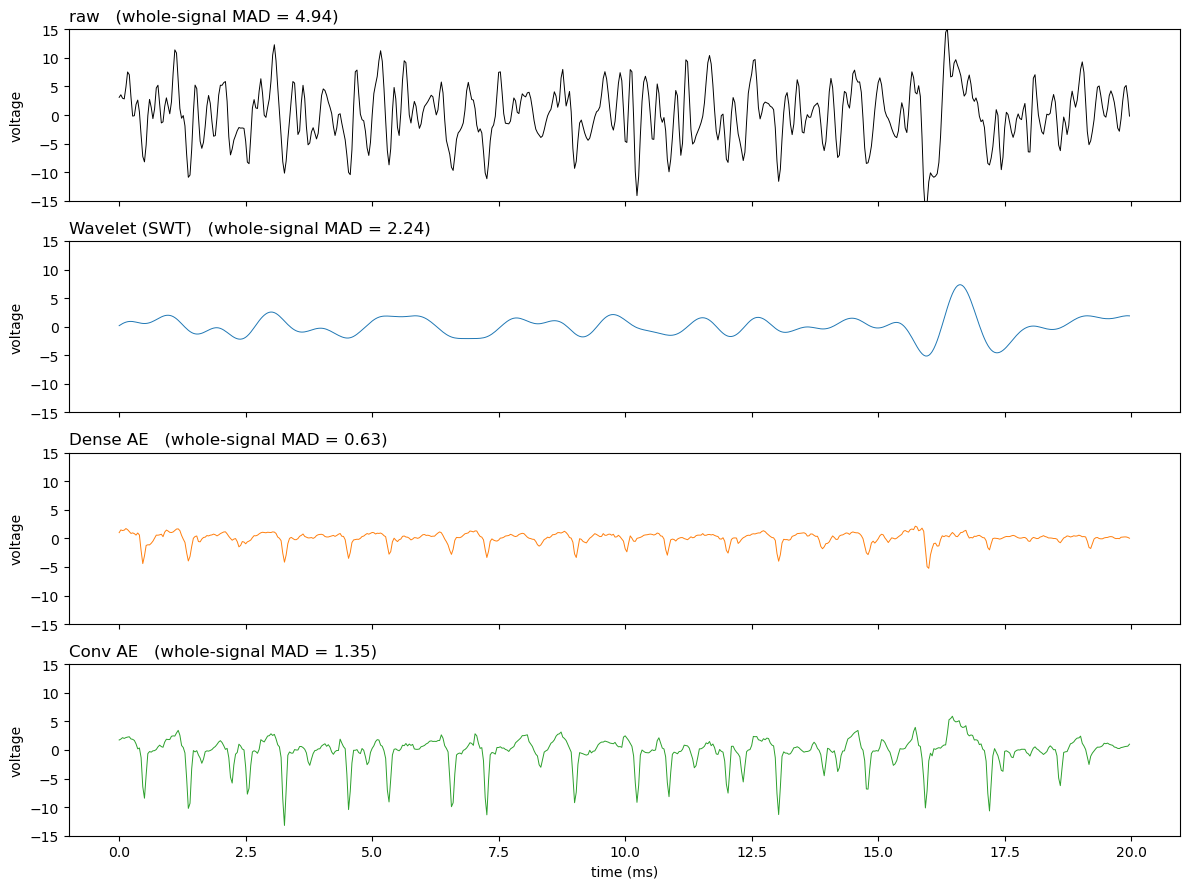

In [115]:
def mad(x):
    return np.median(np.abs(x)) / 0.6745

# whole-signal MADs (representative, computed over all 300 s)
mad_raw = mad(ch19)
mad_wav  = mad(ch19_wavelet)
mad_dense  = mad(ch19_dense)
mad_conv  = mad(ch19_conv)

# a readable zoom window around the first ground-truth spike
centre = int(round((ground_truth_in_window[0] - window_start) * sample_frequency))
half = 300
lo, hi = centre - half, centre + half
time_ms = np.arange(hi - lo) / sample_frequency * 1000

panels = [
    ("raw",      ch19[lo:hi],         mad_raw, "black"),
    ("Wavelet (SWT)", ch19_wavelet[lo:hi], mad_wav,  "tab:blue"),
    ("Dense AE",      ch19_dense[lo:hi],   mad_dense,  "tab:orange"),
    ("Conv AE",       ch19_conv[lo:hi],    mad_conv,  "tab:green"),
]

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True, sharey=True)
for ax, (name, sig, m, colour) in zip(axes, panels):
    ax.plot(time_ms, sig, lw=0.7, color=colour)
    ax.set_title(f"{name}   (whole-signal MAD = {m:.2f})", loc="left")
    ax.set_ylabel("voltage")
axes[-1].set_xlabel("time (ms)")
plt.tight_layout()
plt.ylim(-15, 15)  
plt.show()